In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")

In [12]:
df = pd.read_csv(r"D:\traffic_accident_analysys\data\accident_prediction_india.csv")

In [13]:
df.head()

,State Name,City Name,Year,Month,Day of Week,Time of Day,Accident Severity,Number of Vehicles Involved,Vehicle Type Involved,Number of Casualties,...,Road Type,Road Condition,Lighting Conditions,Traffic Control Presence,Speed Limit (km/h),Driver Age,Driver Gender,Driver License Status,Alcohol Involvement,Accident Location Details
0,Jammu and Kashmir,Unknown,2021,May,Monday,1:46,Serious,5,Cycle,0,...,National Highway,Wet,Dark,Signs,61,66,Male,NaN,Yes,Curve
1,Uttar Pradesh,Lucknow,2018,January,Wednesday,21:30,Minor,5,Truck,5,...,Urban Road,Dry,Dusk,Signs,92,60,Male,NaN,Yes,Straight Road
2,Chhattisgarh,Unknown,2023,May,Wednesday,5:37,Minor,5,Pedestrian,6,...,National Highway,Under Construction,Dawn,Signs,120,26,Female,NaN,No,Bridge
3,Uttar Pradesh,Lucknow,2020,June,Saturday,0:31,Minor,3,Bus,10,...,State Highway,Dry,Dark,Signals,76,34,Female,Valid,Yes,Straight Road
4,Sikkim,Unknown,2021,August,Thursday,11:21,Minor,5,Cycle,7,...,Urban Road,Wet,Dusk,Signs,115,30,Male,NaN,No,Intersection


In [14]:
df.shape
df.columns

Index(['State Name', 'City Name', 'Year', 'Month', 'Day of Week',
       'Time of Day', 'Accident Severity', 'Number of Vehicles Involved',
       'Vehicle Type Involved', 'Number of Casualties', 'Number of Fatalities',
       'Weather Conditions', 'Road Type', 'Road Condition',
       'Lighting Conditions', 'Traffic Control Presence', 'Speed Limit (km/h)',
       'Driver Age', 'Driver Gender', 'Driver License Status',
       'Alcohol Involvement', 'Accident Location Details'],
      dtype='object')

In [15]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   State Name                   3000 non-null   object
 1   City Name                    3000 non-null   object
 2   Year                         3000 non-null   int64 
 3   Month                        3000 non-null   object
 4   Day of Week                  3000 non-null   object
 5   Time of Day                  3000 non-null   object
 6   Accident Severity            3000 non-null   object
 7   Number of Vehicles Involved  3000 non-null   int64 
 8   Vehicle Type Involved        3000 non-null   object
 9   Number of Casualties         3000 non-null   int64 
 10  Number of Fatalities         3000 non-null   int64 
 11  Weather Conditions           3000 non-null   object
 12  Road Type                    3000 non-null   object
 13  Road Condition               3000

,Year,Number of Vehicles Involved,Number of Casualties,Number of Fatalities,Speed Limit (km/h),Driver Age
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000
mean,2020.530000,2.996000,5.066000,2.455333,74.940667,44.17700
std,1.683858,1.428285,3.214097,1.717650,26.765088,15.40286
min,2018.000000,1.000000,0.000000,0.000000,30.000000,18.00000
25%,2019.000000,2.000000,2.000000,1.000000,51.000000,31.00000
50%,2021.000000,3.000000,5.000000,2.000000,75.000000,45.00000
75%,2022.000000,4.000000,8.000000,4.000000,99.000000,57.00000
max,2023.000000,5.000000,10.000000,5.000000,120.000000,70.00000


In [16]:
df.isnull().sum()


State Name                       0
City Name                        0
Year                             0
Month                            0
Day of Week                      0
Time of Day                      0
Accident Severity                0
Number of Vehicles Involved      0
Vehicle Type Involved            0
Number of Casualties             0
Number of Fatalities             0
Weather Conditions               0
Road Type                        0
Road Condition                   0
Lighting Conditions              0
Traffic Control Presence       716
Speed Limit (km/h)               0
Driver Age                       0
Driver Gender                    0
Driver License Status          975
Alcohol Involvement              0
Accident Location Details        0
dtype: int64

In [17]:
df = df.dropna()

In [18]:
df = df.drop_duplicates()

In [19]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [20]:
print("Total Accidents:", len(df))
print("Total Casualties:", df['number_of_casualties'].sum())
print("Total Fatalities:", df['number_of_fatalities'].sum())

Total Accidents: 1565
Total Casualties: 7939
Total Fatalities: 3783


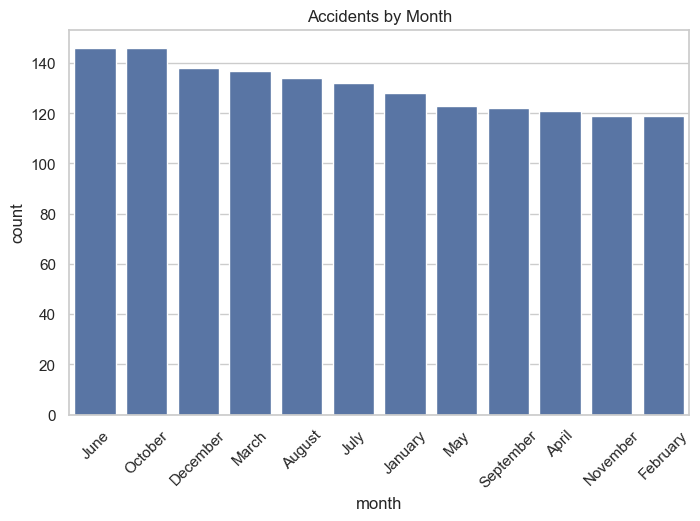

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(x='month', data=df, order=df['month'].value_counts().index)
plt.title("Accidents by Month")
plt.xticks(rotation=45)
plt.show()

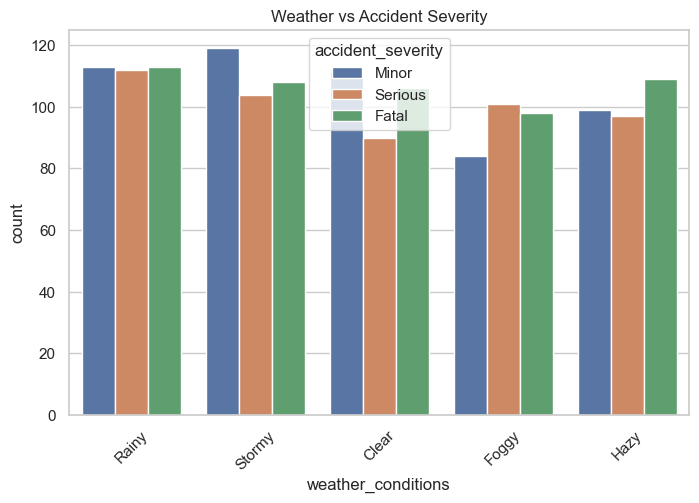

In [22]:
plt.figure(figsize=(8,5))
sns.countplot(x='weather_conditions', hue='accident_severity', data=df)
plt.title("Weather vs Accident Severity")
plt.xticks(rotation=45)
plt.show()

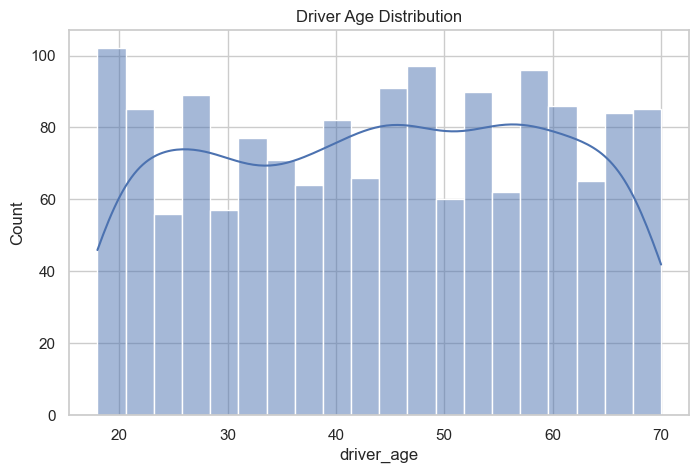

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['driver_age'], bins=20, kde=True)
plt.title("Driver Age Distribution")
plt.show()

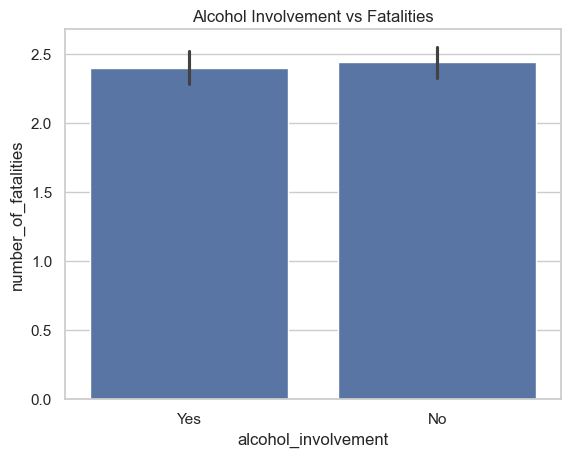

In [24]:
sns.barplot(x='alcohol_involvement', y='number_of_fatalities', data=df)
plt.title("Alcohol Involvement vs Fatalities")
plt.show()

In [26]:
yearly_data = df.groupby('year')['number_of_casualties'].sum().reset_index()

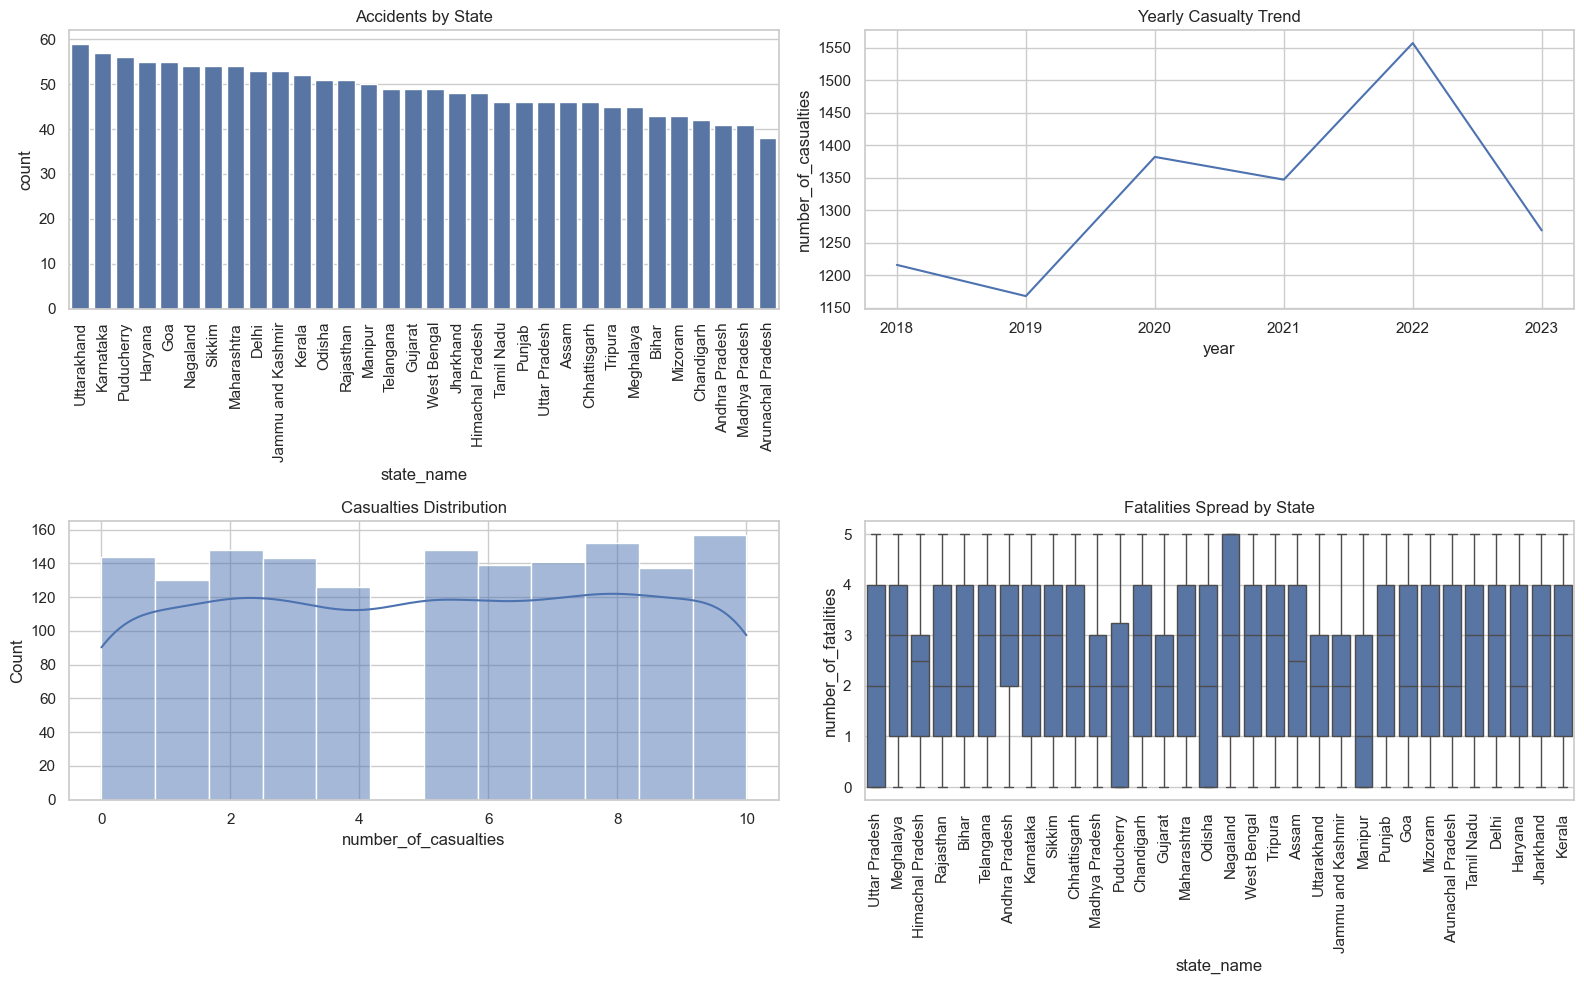

In [28]:
plt.figure(figsize=(16, 10))

# 1. Accidents by State
plt.subplot(2, 2, 1)
sns.countplot(x='state_name', data=df, order=df['state_name'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Accidents by State')

# 2. Yearly Trend
plt.subplot(2, 2, 2)
sns.lineplot(x='year', y='number_of_casualties', data=yearly_data)
plt.title('Yearly Casualty Trend')

# 3. Casualties Distribution
plt.subplot(2, 2, 3)
sns.histplot(df['number_of_casualties'], kde=True)
plt.title('Casualties Distribution')

# 4. State vs Fatalities
plt.subplot(2, 2, 4)
sns.boxplot(x='state_name', y='number_of_fatalities', data=df)
plt.xticks(rotation=90)
plt.title('Fatalities Spread by State')

plt.tight_layout()
plt.show()

In [29]:
contingency_table = pd.crosstab(df['weather_conditions'], df['accident_severity'])

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-Square Test Result")
print("p-value:", p)

if p < 0.05:
    print("Significant relationship")
else:
    print("No significant relationship")

Chi-Square Test Result
p-value: 0.7289657364256213
No significant relationship


In [30]:
df['weather_conditions'].value_counts()

weather_conditions
Rainy     338
Stormy    331
Clear     308
Hazy      305
Foggy     283
Name: count, dtype: int64

In [31]:
# Road condition vs severity
pd.crosstab(df['road_condition'], df['accident_severity'])

# Lighting vs severity
pd.crosstab(df['lighting_conditions'], df['accident_severity'])

# Alcohol involvement vs severity
pd.crosstab(df['alcohol_involvement'], df['accident_severity'])

accident_severity,Fatal,Minor,Serious
alcohol_involvement,,,
No,267,275,237
Yes,267,252,267


In [32]:
contingency_table = pd.crosstab(df['alcohol_involvement'], df['accident_severity'])

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("p-value:", p)

p-value: 0.2517981976498582


In [33]:
stats.chi2_contingency(pd.crosstab(df['road_condition'], df['accident_severity']))

Chi2ContingencyResult(statistic=np.float64(1.415275193324313), pvalue=np.float64(0.9649226156466223), dof=6, expected_freq=array([[121.13099042, 119.54313099, 114.32587859],
       [136.14440895, 134.35974441, 128.49584665],
       [136.82683706, 135.03322684, 129.1399361 ],
       [139.89776358, 138.06389776, 132.03833866]]))

In [34]:
stats.chi2_contingency(pd.crosstab(df['lighting_conditions'], df['accident_severity']))

Chi2ContingencyResult(statistic=np.float64(6.382656593626785), pvalue=np.float64(0.38171648846627687), dof=6, expected_freq=array([[133.41469649, 131.6658147 , 125.91948882],
       [133.75591054, 132.00255591, 126.24153355],
       [127.95527157, 126.27795527, 120.76677316],
       [138.87412141, 137.05367412, 131.07220447]]))

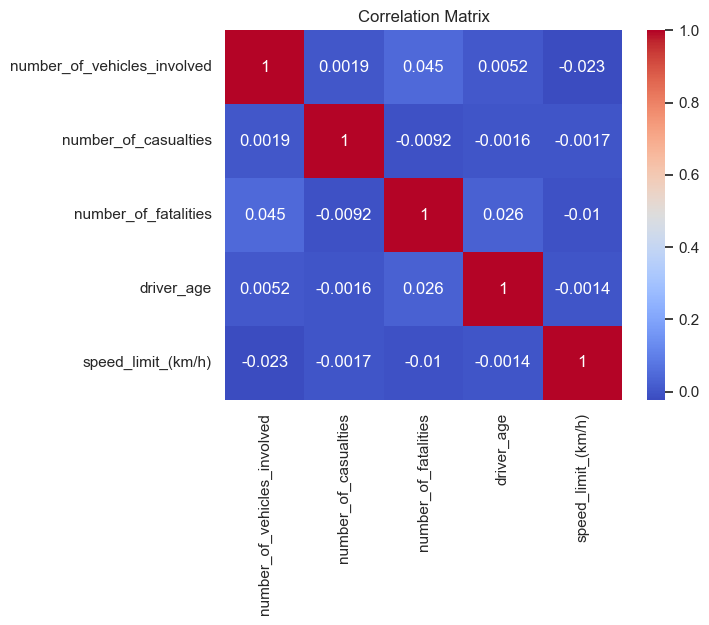

In [37]:
corr = df[['number_of_vehicles_involved', 
           'number_of_casualties', 
           'number_of_fatalities', 
           'driver_age', 
           'speed_limit_(km/h)']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [36]:
df.columns

Index(['state_name', 'city_name', 'year', 'month', 'day_of_week',
       'time_of_day', 'accident_severity', 'number_of_vehicles_involved',
       'vehicle_type_involved', 'number_of_casualties', 'number_of_fatalities',
       'weather_conditions', 'road_type', 'road_condition',
       'lighting_conditions', 'traffic_control_presence', 'speed_limit_(km/h)',
       'driver_age', 'driver_gender', 'driver_license_status',
       'alcohol_involvement', 'accident_location_details'],
      dtype='object')

In [38]:
df.columns = df.columns.str.replace(r"[()\/]", "", regex=True)

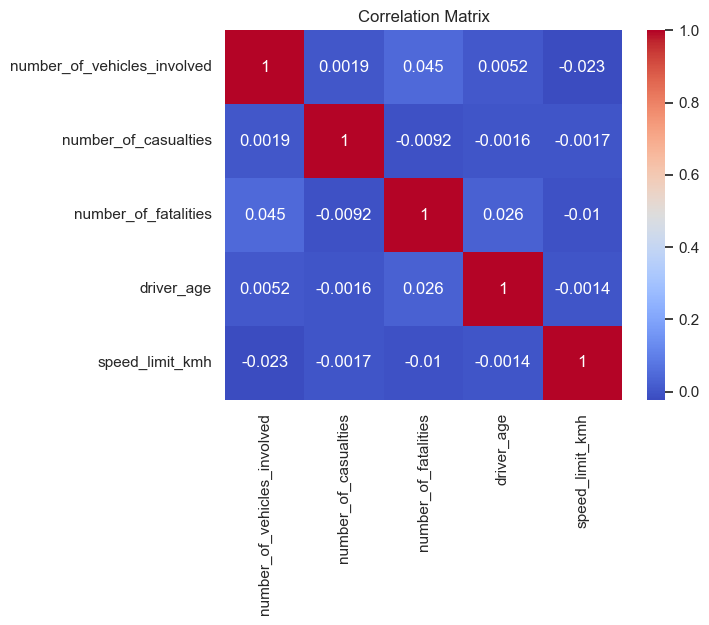

In [39]:
corr = df[['number_of_vehicles_involved', 
           'number_of_casualties', 
           'number_of_fatalities', 
           'driver_age', 
           'speed_limit_kmh']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Minor'),
  Text(1, 0, 'Serious'),
  Text(2, 0, 'Fatal'),
  Text(3, 0, 'Rainy'),
  Text(4, 0, 'Stormy'),
  Text(5, 0, 'Clear'),
  Text(6, 0, 'Foggy'),
  Text(7, 0, 'Hazy'),
  Text(8, 0, 'Dry'),
  Text(9, 0, 'Damaged'),
  Text(10, 0, 'Wet'),
  Text(11, 0, 'Under Construction')])

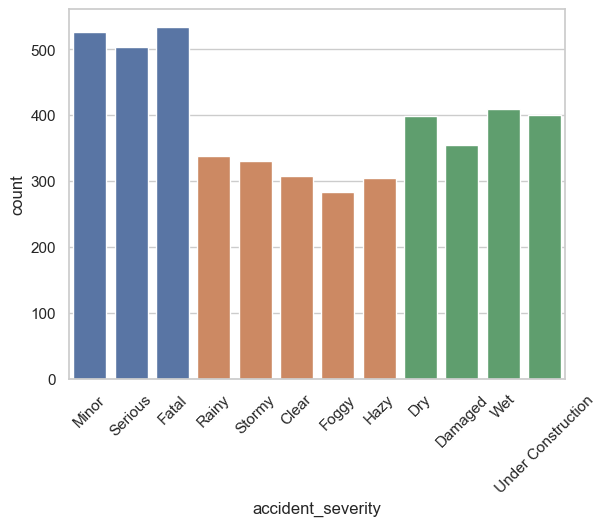

In [41]:
sns.countplot(x='accident_severity', data=df)
sns.countplot(x='weather_conditions', data=df)
sns.countplot(x='road_condition', data=df)
plt.xticks(rotation = 45)

In [42]:
df.groupby('weather_conditions')['number_of_fatalities'].mean()

weather_conditions
Clear     2.324675
Foggy     2.459364
Hazy      2.337705
Rainy     2.606509
Stormy    2.347432
Name: number_of_fatalities, dtype: float64

In [43]:
pd.pivot_table(df, 
               values='number_of_fatalities', 
               index='weather_conditions', 
               columns='accident_severity', 
               aggfunc='mean')

accident_severity,Fatal,Minor,Serious
weather_conditions,,,
Clear,2.132075,2.437500,2.411111
Foggy,2.459184,2.392857,2.514851
Hazy,2.311927,2.131313,2.577320
Rainy,2.442478,2.566372,2.812500
Stormy,2.361111,2.546218,2.105769


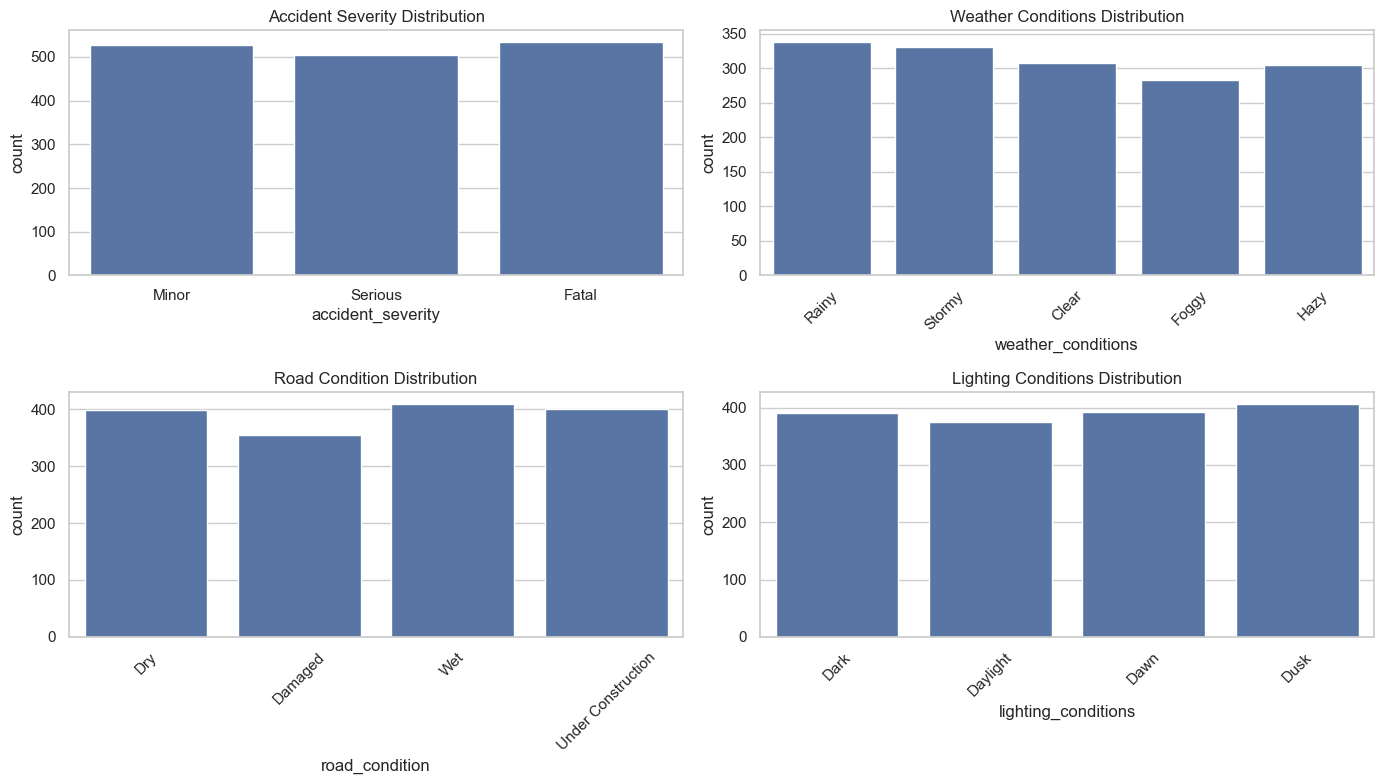

In [44]:
plt.figure(figsize=(14,8))

# Severity Distribution
plt.subplot(2,2,1)
sns.countplot(x='accident_severity', data=df)
plt.title("Accident Severity Distribution")

# Weather Distribution
plt.subplot(2,2,2)
sns.countplot(x='weather_conditions', data=df)
plt.xticks(rotation=45)
plt.title("Weather Conditions Distribution")

# Road Condition
plt.subplot(2,2,3)
sns.countplot(x='road_condition', data=df)
plt.xticks(rotation=45)
plt.title("Road Condition Distribution")

# Lighting Conditions
plt.subplot(2,2,4)
sns.countplot(x='lighting_conditions', data=df)
plt.xticks(rotation=45)
plt.title("Lighting Conditions Distribution")

plt.tight_layout()
plt.show()

In [45]:
weather_fatal = df.groupby('weather_conditions')['number_of_fatalities'].mean().sort_values()

print(weather_fatal)

weather_conditions
Clear     2.324675
Hazy      2.337705
Stormy    2.347432
Foggy     2.459364
Rainy     2.606509
Name: number_of_fatalities, dtype: float64


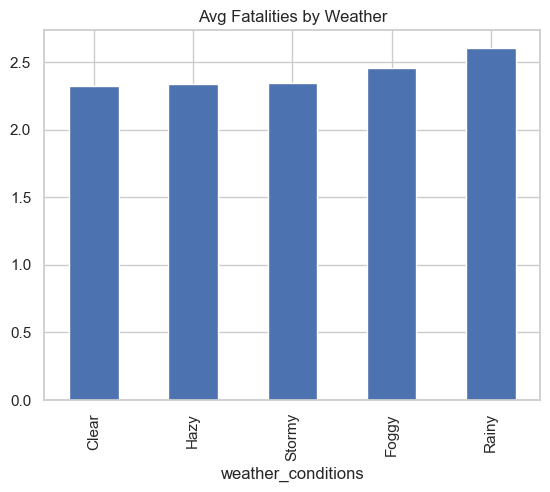

In [46]:
weather_fatal.plot(kind='bar', title='Avg Fatalities by Weather')
plt.show()

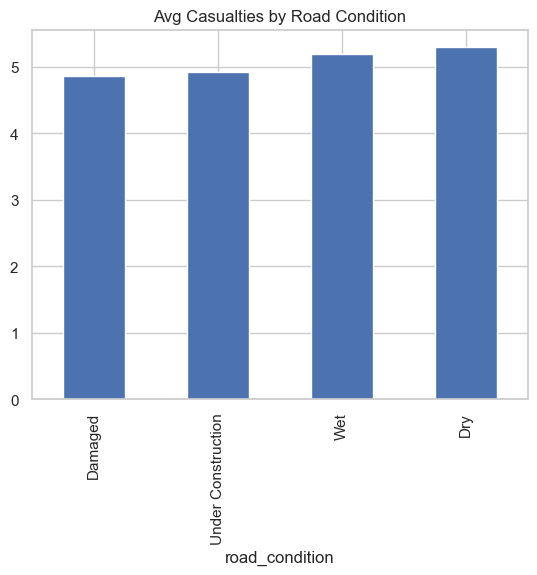

In [47]:
road_casual = df.groupby('road_condition')['number_of_casualties'].mean().sort_values()

road_casual.plot(kind='bar', title='Avg Casualties by Road Condition')
plt.show()

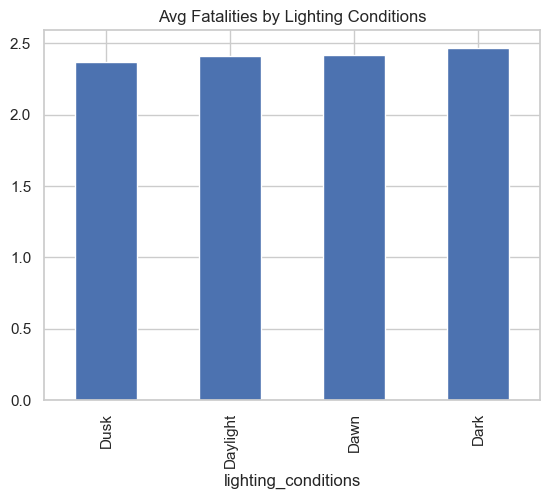

In [48]:
lighting_fatal = df.groupby('lighting_conditions')['number_of_fatalities'].mean().sort_values()

lighting_fatal.plot(kind='bar', title='Avg Fatalities by Lighting Conditions')
plt.show()

In [49]:
alcohol_fatal = df.groupby('alcohol_involvement')['number_of_fatalities'].mean()

print(alcohol_fatal)

alcohol_involvement
No     2.436457
Yes    2.398219
Name: number_of_fatalities, dtype: float64


In [50]:
pivot = pd.pivot_table(df, 
                       values='number_of_fatalities', 
                       index='weather_conditions', 
                       columns='accident_severity', 
                       aggfunc='mean')

print(pivot)

accident_severity      Fatal     Minor   Serious
weather_conditions                              
Clear               2.132075  2.437500  2.411111
Foggy               2.459184  2.392857  2.514851
Hazy                2.311927  2.131313  2.577320
Rainy               2.442478  2.566372  2.812500
Stormy              2.361111  2.546218  2.105769


In [51]:
pivot2 = pd.pivot_table(df, 
                        values='number_of_casualties', 
                        index='road_condition', 
                        columns='accident_severity', 
                        aggfunc='mean')

print(pivot2)

accident_severity      Fatal     Minor   Serious
road_condition                                  
Damaged             4.596774  4.890756  5.133929
Dry                 5.720930  5.253731  4.926471
Under Construction  4.911765  4.949640  4.896825
Wet                 5.158621  5.355556  5.046154


In [53]:
# Key Insights:

# - No strong statistical relationships were found between categorical variables and accident severity.
# - Numerical variables showed negligible correlation.
# - Group-based analysis revealed minor variations in fatalities across weather and road conditions.
# - The dataset appears uniformly distributed, limiting inferential conclusions.

In [54]:
df.to_csv("cleaned_accidents.csv", index=False)